### Function: `get_sequences_from_file`

This function reads a FASTA file containing DNA sequences and returns a dictionary that maps each penguin species name to its DNA sequence.

- **Input:**
  - `fasta_fn` (str): The path to a FASTA file containing nucleotide sequences. Each sequence record should include the species name in the second and third word of its description line.

- **Output:**
  - A dictionary (`dict`) where:
    - **Keys** are species names as strings (e.g., `"Aptenodytes forsteri"`)
    - **Values** are `Bio.Seq.Seq` objects representing the corresponding DNA sequences.

The function uses Biopython's `SeqIO.parse()` to read the FASTA file.


In [2]:
from Bio import SeqIO

def get_sequences_from_file(fasta_fn):
    """
    Reads a FASTA file and returns a dictionary mapping species names to their DNA sequences.

    Parameters:
    fasta_fn (str): Path to the FASTA file containing DNA sequences.

    Returns:
    dict: A dictionary where keys are species names (e.g., "Aptenodytes forsteri")
          and values are Biopython Seq objects representing nucleotide sequences.
    """
    sequence_data_dict = {}
    for record in SeqIO.parse(fasta_fn, "fasta"):
        description = record.description.split()
        species_name = description[1] + " " + description[2]
        sequence_data_dict[species_name] = record.seq
    return sequence_data_dict


### Function: `translate_to_aa`

This function takes a nucleotide sequence (DNA string) and returns the corresponding amino acid sequence, based on the Vertebrate Mitochondrial genetic code, which is appropriate for translating mitochondrial genes like cytochrome-b in penguins.

- **Input:**
  - `nucleotide_string` (str): A string of DNA nucleotides. Assumes the reading frame starts at position 1 and is in the 5' to 3' direction.

- **Output:**
  - A string representing the translated amino acid sequence. 
  - If a stop codon is encountered, translation stops and the stop codon is excluded.
  - Unknown codons are translated as `"X"` to indicate ambiguity.

This function uses Biopython’s `CodonTable` to access the Vertebrate Mitochondrial codon table and manually iterates through the sequence in triplets (codons), converting each codon to its corresponding amino acid.


In [5]:
from Bio.Data import CodonTable

def translate_to_aa(nucleotide_string):
    mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]
    aa_seq_string = ""

    for i in range(0, len(nucleotide_string) - 2, 3):  # step by 3 for each codon
        codon = nucleotide_string[i:i+3]
        if codon in mito_table.stop_codons:
            break  # Stop translation if a stop codon is found
        elif codon in mito_table.forward_table:
            aa_seq_string += mito_table.forward_table[codon]
        else:
            aa_seq_string += "X"  # Unknown/ambiguous codon

    return aa_seq_string


In [7]:
# Sample mini test
test_dna = "ATGGTAGCTTAA"  # ATG (M), GTA (V), GCT (A), TAA is a stop codon
print(translate_to_aa(test_dna))  # Output should be something like 'MVA'


MVA


### Function: `translate_with_biopython`

This function uses Biopython's built-in `Seq.translate()` method to convert a nucleotide sequence into an amino acid sequence, using the Vertebrate Mitochondrial genetic code.

- **Input:**
  - `nucleotide_string` (str): A string of DNA nucleotides from a coding region (e.g., cytochrome-b gene).

- **Output:**
  - A string representing the translated amino acid sequence.
  - Translation automatically stops at the first stop codon and excludes it from the final result.

This is a more efficient and readable alternative to a manual codon-by-codon translation, leveraging Biopython’s internal optimizations.


In [10]:
from Bio.Seq import Seq
from Bio.Data import CodonTable

def translate_with_biopython(nucleotide_string):
    dna_seq = Seq(nucleotide_string)
    # Translate using Vertebrate Mitochondrial table, and stop_symbol="*" so we can strip it if needed
    protein_seq = dna_seq.translate(table="Vertebrate Mitochondrial", to_stop=True)
    return str(protein_seq)


In [12]:
test_dna = "ATGGTAGCTTAA"  # should give 'MVA'
translate_with_biopython(test_dna)


'MVA'

### Function: `compute_molecular_weight`

This function calculates the molecular weight of a translated amino acid sequence using Biopython’s `ProteinAnalysis` class from the `SeqUtils.ProtParam` module.

- **Input:**
  - `aa_seq` (str): A string representing the amino acid sequence. Should not contain stop codons (e.g., '*').

- **Output:**
  - A float representing the molecular weight in Daltons (Da).

Behind the scenes, the function creates a `ProteinAnalysis` object and calls its `molecular_weight()` method, which computes the weight based on the average isotopic masses of each amino acid.


In [15]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def compute_molecular_weight(aa_seq):
    
    analyzed_seq = ProteinAnalysis(aa_seq)
    return analyzed_seq.molecular_weight()


In [17]:
test_aa = "MVA"  # Methionine + Valine + Alanine
compute_molecular_weight(test_aa)


319.42019999999997

### Function: `calculate_gc_content`

This function computes the GC content of a DNA sequence, which is the proportion of nucleotides that are either Guanine (G) or Cytosine (C).

- **Input:**
  - `dna_seq` (str or Biopython `Seq`): A DNA sequence (typically from the FASTA file). The input can be uppercase or lowercase.

- **Output:**
  - A float between 0 and 1 representing the GC content (e.g., 0.55 = 55% GC).

The function works by counting how many G and C bases are in the sequence, summing them, and dividing by the total length of the sequence.


In [21]:
def calculate_gc_content(dna_seq):
    """
    Calculates the GC content (as a proportion between 0 and 1) of a given DNA sequence.

    Parameters:
    dna_seq (str or Seq): The nucleotide sequence to analyze.

    Returns:
    float: Proportion of nucleotides that are G or C (GC content).
    """
    seq_upper = dna_seq.upper()
    g_count = seq_upper.count("G")
    c_count = seq_upper.count("C")
    total = len(seq_upper)
    
    if total == 0:
        return 0.0
    
    return (g_count + c_count) / total


In [25]:
calculate_gc_content("ATGCGCGTA")  # Should return something like 0.5556


0.5555555555555556

### Step 6: Initialize New Data Columns

Before we calculate the molecular weight and GC content of the penguin cytochrome-b sequences, we first add two new columns to the `penguins_df` DataFrame:

- `molecular_weight`: will store the molecular weight of each translated amino acid sequence.
- `gc_content`: will store the GC content of each nucleotide sequence.

We initialize the values to `NaN` using NumPy, which allows us to populate them later during the loop over species.


In [33]:
import pandas as pd  # Import Pandas as pd
cytb_seqs = get_sequences_from_file("penguins_cytb.fasta") 
penguins_df = pd.read_csv("penguins_mass.csv")  # This loads the DataFrame with body mass data
species_list = list(penguins_df.species)        # Optional: a list of species names


In [35]:
import numpy as np  # needed for NaN

# Add empty columns for molecular weight and GC content
penguins_df["molecular_weight"] = np.nan
penguins_df["gc_content"] = np.nan


### Step 7: Loop to Translate Sequences and Add Data to DataFrame

In this step, we loop through each species and its corresponding cytochrome-b (cytb) sequence, translating the DNA sequence, calculating the molecular weight, and computing the GC content. These values are then added to the `penguins_df` DataFrame.

- **Loop:** For each species in the `cytb_seqs` dictionary, the DNA sequence is translated to an amino acid sequence.
- **Translation:** We use either the custom `translate_to_aa()` or the `translate_with_biopython()` function to obtain the translated amino acid sequence.
- **Molecular Weight:** The molecular weight of the amino acid sequence is calculated using the `compute_molecular_weight()` function.
- **GC Content:** The GC content of the original DNA sequence is calculated with the `calculate_gc_content()` function.
- **DataFrame Update:** The calculated values are then stored in the appropriate columns (`molecular_weight`, `gc_content`) in the `penguins_df` DataFrame for each species.

This loop allows us to populate the empty columns with meaningful data for further analysis.


In [40]:
# Iterate through each species and their corresponding nucleotide sequence
for species, dna_seq in cytb_seqs.items():
    # Translate DNA sequence to amino acid sequence (use the function you prefer)
    aa_seq = translate_with_biopython(dna_seq)  # Or use translate_to_aa(dna_seq)
    
    # Calculate molecular weight of the amino acid sequence
    molecular_weight = compute_molecular_weight(aa_seq)
    
    # Calculate GC content of the original DNA sequence
    gc_content = calculate_gc_content(dna_seq)
    
    # Add these values to the DataFrame
    penguins_df.loc[penguins_df.species == species, "molecular_weight"] = molecular_weight
    penguins_df.loc[penguins_df.species == species, "gc_content"] = gc_content


In [42]:
penguins_df.head()  # Display the first few rows of the DataFrame to see the results


,species,mass,molecular_weight,gc_content
0,Aptenodytes forsteri,28.00,42459.6021,0.483815
1,Aptenodytes patagonicus,13.40,42563.7067,0.496938
2,Eudyptes chrysocome,2.80,42475.5753,0.511811
3,Eudyptes chrysolophus,4.50,42445.5493,0.509186
4,Eudyptes sclateri,4.25,42475.5753,0.508311


### Step 8: Bar Chart of Penguin Mass

This step creates a bar chart visualizing the mass of different penguin species. The `species` names are plotted on the x-axis, and the `mass` (in kilograms) is plotted on the y-axis.

- **Plotting:** We use `matplotlib.pyplot.bar()` to generate a bar chart. The `species` column is used for the x-axis, and the `mass` column is used for the y-axis.
- **Labels & Title:** The chart is labeled with appropriate axis labels ("Species" and "Mass (kg)") and a title ("Penguin Species Mass").
- **Rotation:** The x-axis labels (species names) are rotated for readability.

This chart will help visually compare the masses of different penguin species.


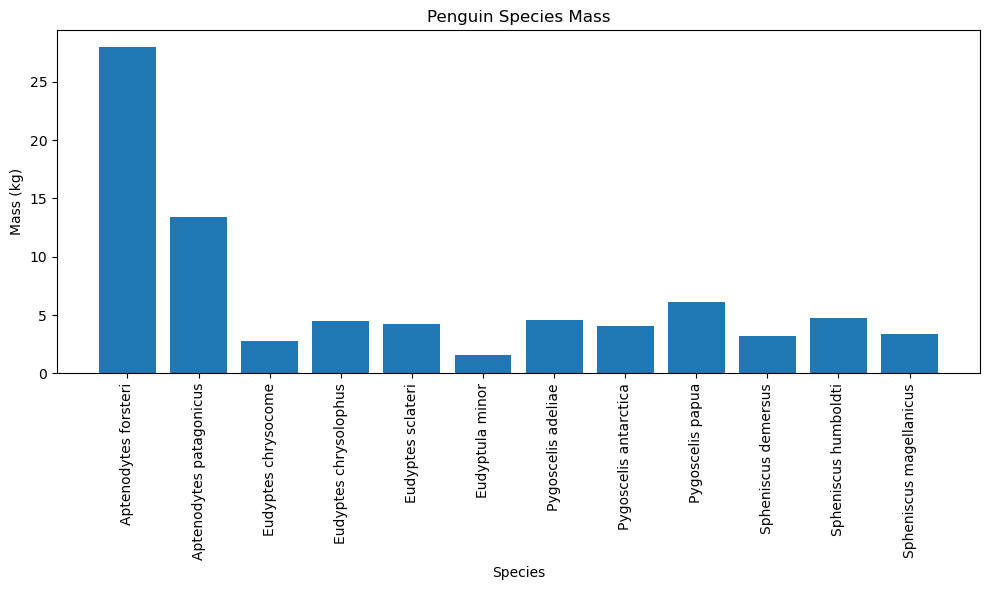

In [45]:
import matplotlib.pyplot as plt

# Plotting a bar chart of mass with species names on the x-axis
plt.figure(figsize=(10, 6))
plt.bar(penguins_df['species'], penguins_df['mass'])

# Add labels and title
plt.xlabel('Species')
plt.ylabel('Mass (kg)')
plt.title('Penguin Species Mass')

# Rotate x-axis labels to make them readable
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()


### Graph description: 
Looking at the above graph, we can easily see that Eudyptula minor is the smallest of the species by mass. This penguin comes from New Zealand.

### Step 9: Scatter Plot of Molecular Weight vs. GC Content

This scatter plot shows the relationship between the molecular weight of each translated protein sequence (y-axis) and the GC content of each species' DNA sequence (x-axis).

- **Plotting:** We use `matplotlib.pyplot.scatter()` to create the scatter plot, with the GC content on the x-axis and molecular weight on the y-axis.
- **Labels & Title:** The axes are labeled with "GC Content (%)" and "Molecular Weight (g/mol)", and the plot is given a descriptive title.

This plot helps us investigate any potential correlation between GC content and the molecular weight of proteins in the penguin species.


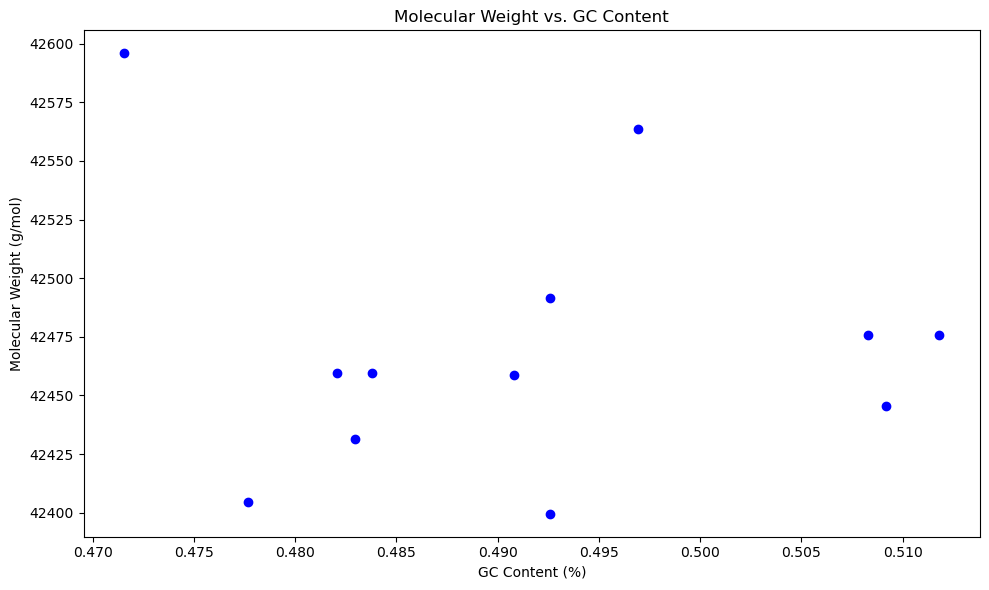

In [50]:
# Plotting a scatter plot of molecular weight vs. GC content
plt.figure(figsize=(10, 6))
plt.scatter(penguins_df['gc_content'], penguins_df['molecular_weight'], color='blue')

# Add labels and title
plt.xlabel('GC Content (%)')
plt.ylabel('Molecular Weight (g/mol)')
plt.title('Molecular Weight vs. GC Content')

# Show the plot
plt.tight_layout()
plt.show()


### Step 10: Save DataFrame to CSV

In this step, we save the updated `penguins_df` DataFrame, which now includes molecular weight and GC content data, to a CSV file called `"penguins_mass_cytb.csv"`. This allows us to store and share the processed data for further analysis.

- **Saving:** We use `pandas.DataFrame.to_csv()` to save the DataFrame to a CSV file. The `index=False` argument ensures that the row indices are not written to the file.


In [53]:
# Save the DataFrame to a CSV file
penguins_df.to_csv("penguins_mass_cytb.csv", index=False)


### Step 11: BONUS 

This is the optional analysis I chose to do with the dataset:

1. **Correlation Analysis:** Calculate and visualize the correlation matrix to understand relationships between the numeric variables in the dataset (mass, molecular weight, GC content).



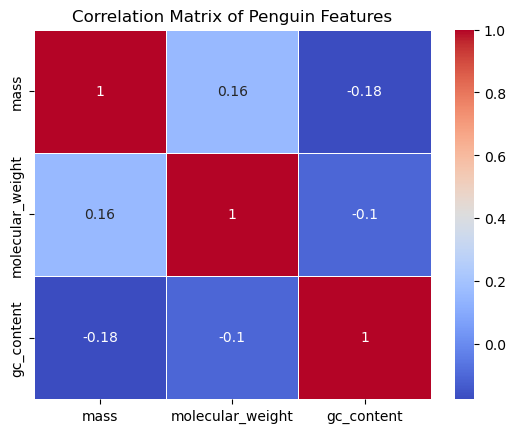

In [56]:
# Calculate correlation matrix
correlation_matrix = penguins_df[['mass', 'molecular_weight', 'gc_content']].corr()

# Plot the correlation matrix
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Penguin Features')
plt.show()
